## COMPAS - 2 OBJECTIVES

### Multi Layer Perceptron

* **Dataset:** Compass
* **Task:** Classification
* **Target:** Two year recidivism
* **Objectives:** Non-white and White individuals

In [24]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [25]:
import numpy as np
import pandas as pd

from sklearn.metrics import log_loss
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim

In [26]:
from machinemoo import moo
from machinemoo import get_objectives, get_models
from machinemoo.analysis.visualization import plot_pareto, plot_multiple_hypervolumes
from machinemoo.analysis.metrics import compute_hypervolume_progress

from scalarization import MLPScalarization

### Dataset and Model

In [27]:
# Setting a seed for reproducibility
seed = 42

In [28]:
import random
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [29]:
data = pd.read_csv("dataset/compas_onerace.csv")
data = data.drop("Unnamed: 0", axis=1)

fair_feature = "not_white"
pred_feature = "Two_yr_Recidivism"

categories_fair_class = []

for index, row in data.iterrows():
    if row[pred_feature] == -1:
        categories_fair_class.append(row[fair_feature])
    else:
        categories_fair_class.append(row[fair_feature]+2)

X = data.drop([pred_feature], axis=1)
# y = data[pred_feature]
y = (data[pred_feature] + 1)//2

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size = int(data.shape[0]*0.5),
                                                    stratify = categories_fair_class,
                                                    random_state = seed)

## MOO Modeling and Training

* MOO methods:
    * MOLA
    * MONISE
    * Random Weights

In [30]:
# Setting optimization parameter to use in all methods in this experiment
opt_params = {
    'node_time_limit': 2,
    'target_size': 500,
    'target_gap': 0,
    'node_gap': 0.05,
    'norm': False
}
num_objs = 2
results = {}

max_iter = 100

In [31]:
# Logistic Regression with equal weight to use as baseline model
equal = MLPScalarization(
                        num_objs=2,
                        X=X_train, 
                        y=y_train, 
                        fair_feat=fair_feature,
                        max_iter=max_iter,
                        lower_bound_estimate="lipshitz",  # Options: "zero", "lipshitz", or a float value
                    )
equal.optimize(np.array([1, 0]))

Lipschitz constants for each group: [ 5.37464952 12.18032742]


## MOLA

In [32]:
np.linalg.norm(equal.w@np.array(equal.gradient))**2/(equal.w@equal.L)

np.float64(7.4434218556101915e-06)

19:19:07 | DEBUG | machinemoo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 500, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}


19:19:07 | DEBUG | machinemoo | Finding 1th individual minimum
19:19:07 | DEBUG | machinemoo | Finding 2th individual minimum
19:19:07 | DEBUG | machinemoo | Calculated weights: [0.52081883 0.47918117]
19:19:07 | DEBUG | machinemoo | Importance: 0.017331325796189623
19:19:07 | DEBUG | machinemoo | Importance: 0.017331325796189567
19:19:07 | DEBUG | machinemoo | Global lower bound (y*): [0.58877859 0.59373163]
19:19:07 | DEBUG | machinemoo | Iteration 1
19:19:07 | DEBUG | machinemoo | Solutions list: [array([0.59472585, 0.62343624]), array([0.61653784, 0.59972892])]
19:19:08 | DEBUG | machinemoo | New solution added [0.59379603 0.60009515]
19:19:08 | DEBUG | machinemoo | Solution dominated [0.59472585 0.62343624]
19:19:08 | DEBUG | machinemoo | Calculated weights: [0.01585083 0.98414917]
19:19:08 | DEBUG | machinemoo | Importance: 0.006356770659163736
19:19:08 | DEBUG | machinemoo | Importance: 0.006356770659163735
19:19:08 | DEBUG | machinemoo | Global lower bound (y*): [0.58785807 0.5

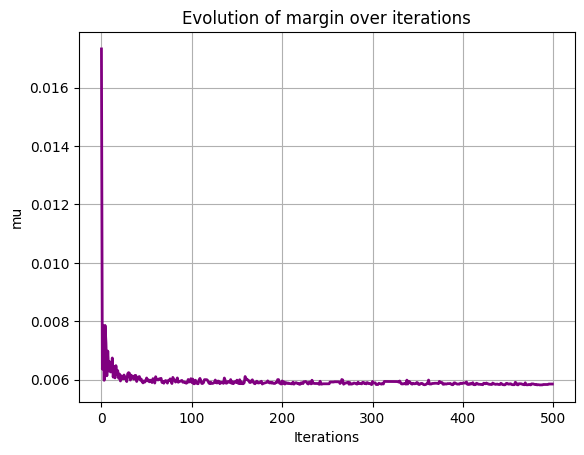

19:20:14 | INFO | machinemoo | Fit runtime: 67.10 seconds


In [33]:
method = 'mola'
w_scalar = MLPScalarization(num_objs=2, 
                            X=X_train, 
                            y=y_train,
                            fair_feat=fair_feature,
                            max_iter=max_iter,
                            lower_bound_estimate=0.01
                            )
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = moopt.get_hypervolumes()
results[method] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

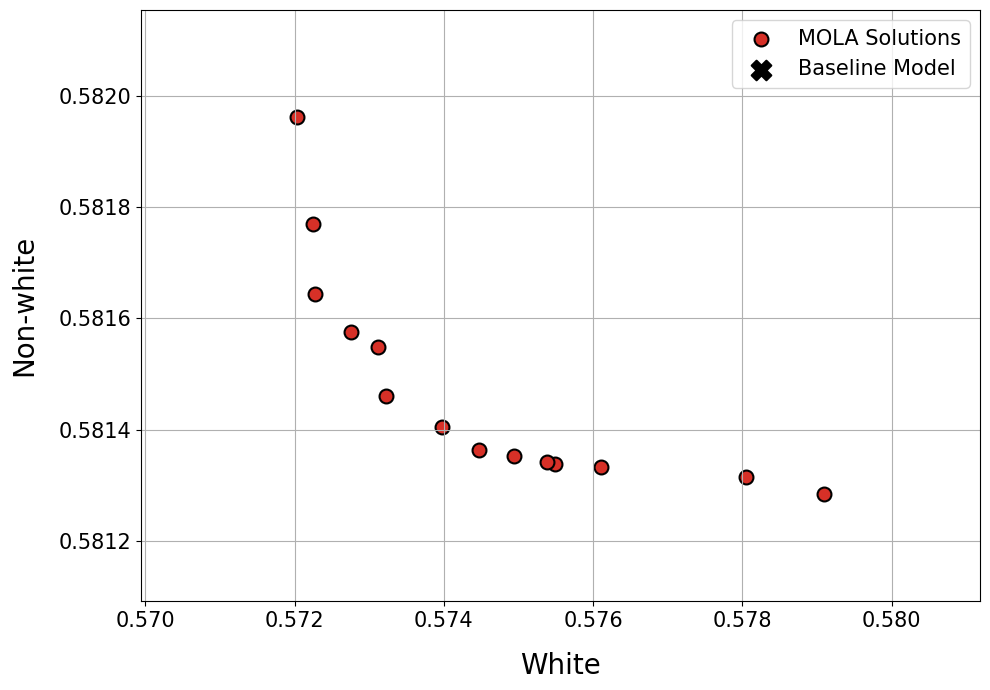

In [34]:
title="Loss Trade-offs for White and Non-White Person"
plot_pareto(methods={'mola': results['mola']['objectives']},
            labels=("White", "Non-White"), 
            title=title,
            point=equal.objs,
            fontsize=20,
            figsize=(10,7),
            save_path='images/2_objs_mlp_mola.pdf'
            )

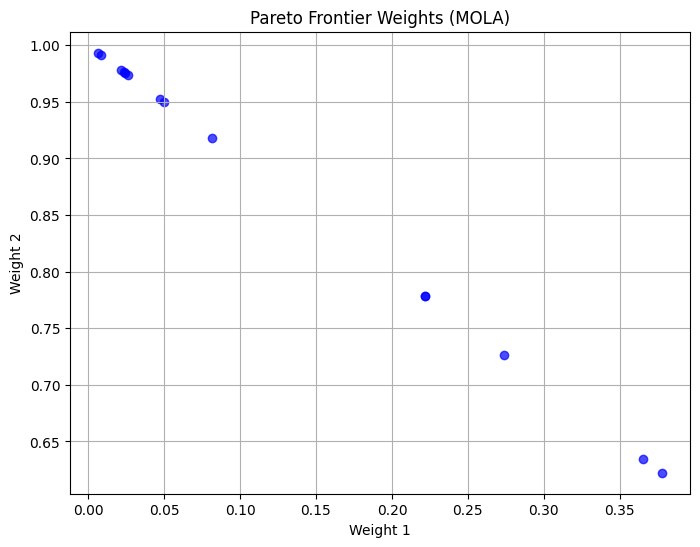

In [35]:
import matplotlib.pyplot as plt

pareto_models = results['mola']['models']
weights = np.array([sol.w for sol in results['mola']["moopt"].solutions_list])

plt.figure(figsize=(8,6))
plt.scatter(weights[:, 0], weights[:, 1], c='b', alpha=0.7)
plt.xlabel('Weight 1')
plt.ylabel('Weight 2')
plt.title('Pareto Frontier Weights (MOLA)')
plt.grid(True)
plt.show()

19:20:15 | DEBUG | machinemoo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 500, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}
19:20:15 | DEBUG | machinemoo | Finding 1th individual minimum
19:20:15 | DEBUG | machinemoo | Finding 2th individual minimum


Lipschitz constants for each group: [ 6.23876953 13.2007885 ]


19:20:15 | DEBUG | machinemoo | Calculated weights: [0.5483242 0.4516758]
19:20:15 | DEBUG | machinemoo | Importance: 0.010763649990592206
19:20:15 | DEBUG | machinemoo | Importance: 0.010763649990592206
19:20:15 | DEBUG | machinemoo | Global lower bound (y*): [0.59452942 0.59954866]
19:20:15 | DEBUG | machinemoo | Iteration 1
19:20:15 | DEBUG | machinemoo | Solutions list: [array([0.5945537 , 0.62334966]), array([0.61415739, 0.59955123])]
19:20:15 | DEBUG | machinemoo | New solution added [0.59421896 0.60190059]
19:20:15 | DEBUG | machinemoo | Solution dominated [0.5945537  0.62334966]
19:20:15 | DEBUG | machinemoo | Calculated weights: [0.10541076 0.89458924]
19:20:15 | DEBUG | machinemoo | Importance: 0.0021047067852916768
19:20:15 | DEBUG | machinemoo | Importance: 0.0021047067852916213
19:20:15 | DEBUG | machinemoo | Global lower bound (y*): [0.59421121 0.59954866]
19:20:15 | DEBUG | machinemoo | Iteration 2
19:20:15 | DEBUG | machinemoo | Solutions list: [array([0.59421896, 0.601

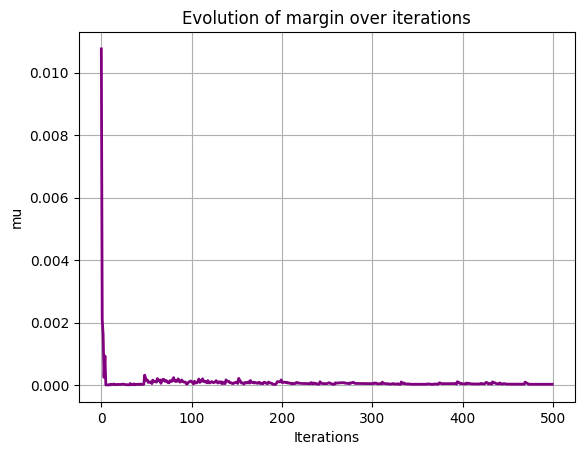

19:21:34 | INFO | machinemoo | Fit runtime: 79.23 seconds


In [36]:
method = 'mola'
w_scalar = MLPScalarization(num_objs=2, 
                            X=X_train, 
                            y=y_train,
                            fair_feat=fair_feature,
                            max_iter=max_iter,
                            lower_bound_estimate="lipshitz"  # Options: "zero", "lipshitz", or a float value
                            )
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = moopt.get_hypervolumes()
results[f"{method}_grad"] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

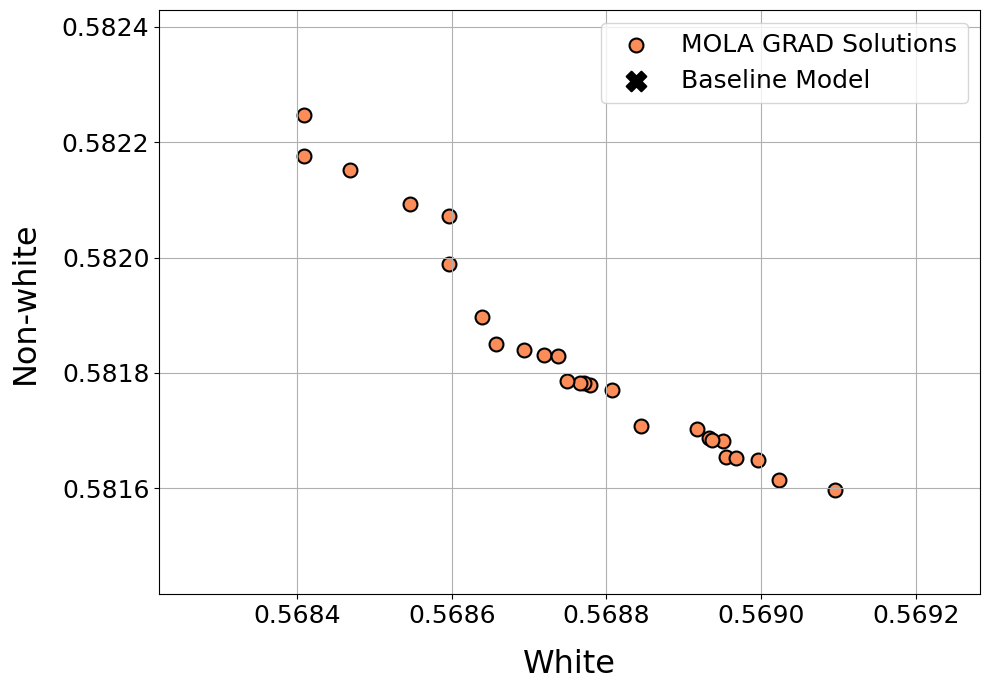

In [37]:
title="Loss Trade-offs for White and Non-White Person"
plot_pareto(methods={'mola_grad': results['mola_grad']['objectives']},
            color='#fc8d59',
            labels=("White", "Non-White"), 
            title=title,
            point=equal.objs,
            fontsize=23,
            figsize=(10,7),
            save_path='images/2_objs_mlp_mola_grad.pdf'
            )

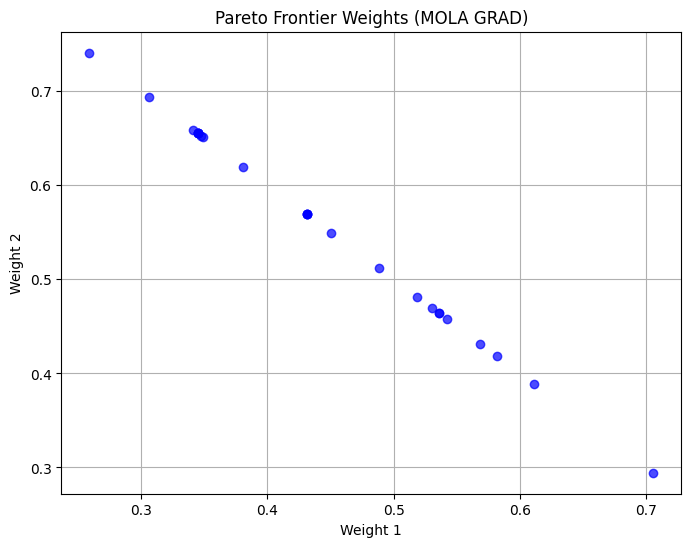

In [38]:
import matplotlib.pyplot as plt

pareto_models = results['mola_grad']['models']
weights = np.array([sol.w for sol in results['mola_grad']["moopt"].solutions_list])

plt.figure(figsize=(8,6))
plt.scatter(weights[:, 0], weights[:, 1], c='b', alpha=0.7)
plt.xlabel('Weight 1')
plt.ylabel('Weight 2')
plt.title('Pareto Frontier Weights (MOLA GRAD)')
plt.grid(True)
plt.show()

## Random Weight

In [39]:
method = 'random_weight'
w_scalar = MLPScalarization(num_objs=2, 
                            X=X_train, 
                            y=y_train,
                            fair_feat=fair_feature,
                            max_iter=max_iter,
                            lower_bound_estimate="lipshitz"  # Options: "zero", "lipshitz", or a float value
                            )
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = compute_hypervolume_progress(objs)
results[method] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

19:21:34 | WARNING | machinemoo | Ignored parameters for random_weights: {'nodeTimeLimit', 'nodeGap', 'targetGap'}
19:21:34 | DEBUG | machinemoo | Filtered parameters for random_weights: {'targetSize': 500, 'norm': False}
19:21:34 | DEBUG | machinemoo | Finding 1th individual minima
19:21:34 | DEBUG | machinemoo | Finding 2th individual minima


Lipschitz constants for each group: [ 5.87568665 13.29071808]


19:21:35 | DEBUG | machinemoo | 3th solution
19:21:35 | DEBUG | machinemoo | 4th solution
19:21:35 | DEBUG | machinemoo | 5th solution
19:21:35 | DEBUG | machinemoo | 6th solution
19:21:35 | DEBUG | machinemoo | 7th solution
19:21:35 | DEBUG | machinemoo | 8th solution
19:21:35 | DEBUG | machinemoo | 9th solution
19:21:35 | DEBUG | machinemoo | 10th solution
19:21:36 | DEBUG | machinemoo | 11th solution
19:21:36 | DEBUG | machinemoo | 12th solution
19:21:36 | DEBUG | machinemoo | 13th solution
19:21:36 | DEBUG | machinemoo | 14th solution
19:21:36 | DEBUG | machinemoo | 15th solution
19:21:36 | DEBUG | machinemoo | 16th solution
19:21:36 | DEBUG | machinemoo | 17th solution
19:21:36 | DEBUG | machinemoo | 18th solution
19:21:37 | DEBUG | machinemoo | 19th solution
19:21:37 | DEBUG | machinemoo | 20th solution
19:21:37 | DEBUG | machinemoo | 21th solution
19:21:37 | DEBUG | machinemoo | 22th solution
19:21:37 | DEBUG | machinemoo | 23th solution
19:21:37 | DEBUG | machinemoo | 24th solu

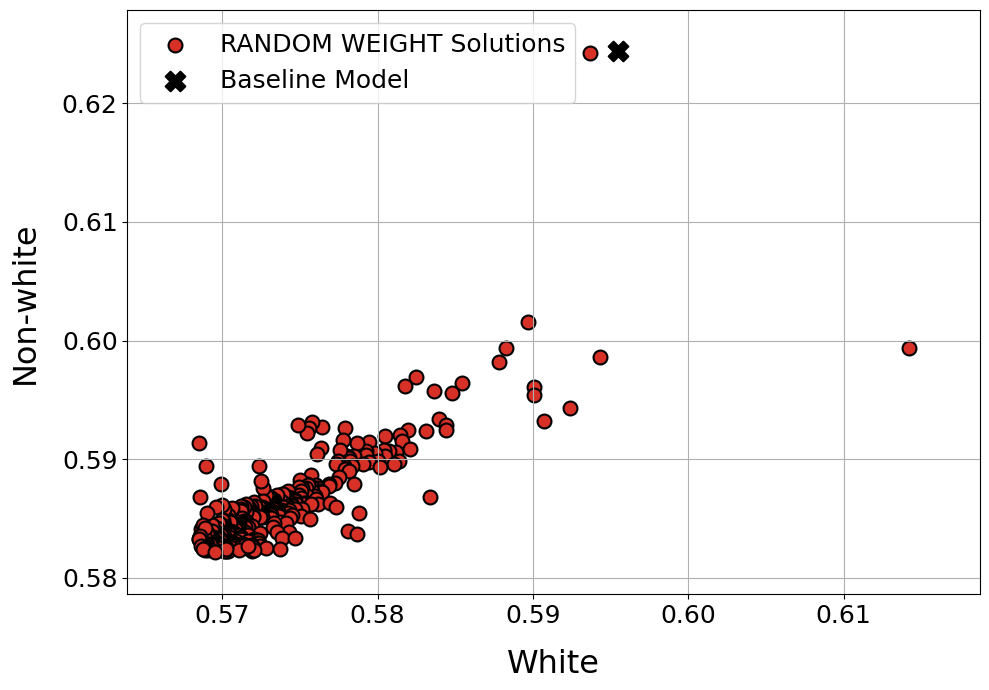

In [40]:
title="Loss Trade-offs for White and Non-White Person"
plot_pareto(methods={'random_weight': objs},
            labels=("White", "Non-White"), 
            title=title,
            point=equal.objs,
            fontsize=23,
            figsize=(10,7),
            save_path='images/2_objs_mlp_mola_rw.pdf'
            )

In [41]:
import numpy as np
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting

# Supondo que `solutions` seja seu array (N x M)
solutions = results['random_weight']['objectives']

# Identifica os índices das soluções não-dominadas
nd_indices = NonDominatedSorting().do(solutions, only_non_dominated_front=True)

# Extrai as soluções não-dominadas
non_dominated_solutions = solutions[nd_indices]

print(f"Número de soluções não-dominadas: {len(non_dominated_solutions)}")
print(non_dominated_solutions)

Número de soluções não-dominadas: 9
[[0.56848564 0.59136705]
 [0.56851636 0.58325354]
 [0.56875895 0.58262404]
 [0.56865523 0.58268845]
 [0.56907961 0.58238805]
 [0.56886601 0.582469  ]
 [0.56888669 0.58238849]
 [0.56875929 0.58247701]
 [0.56952245 0.58220974]]


In [42]:
len(results['mola']['objectives'])

14

In [43]:
len(results['mola_grad']['objectives'])

26

## A posteriori Decision Making

* Comparison between MOO methods
* Ensemble and Evaluation

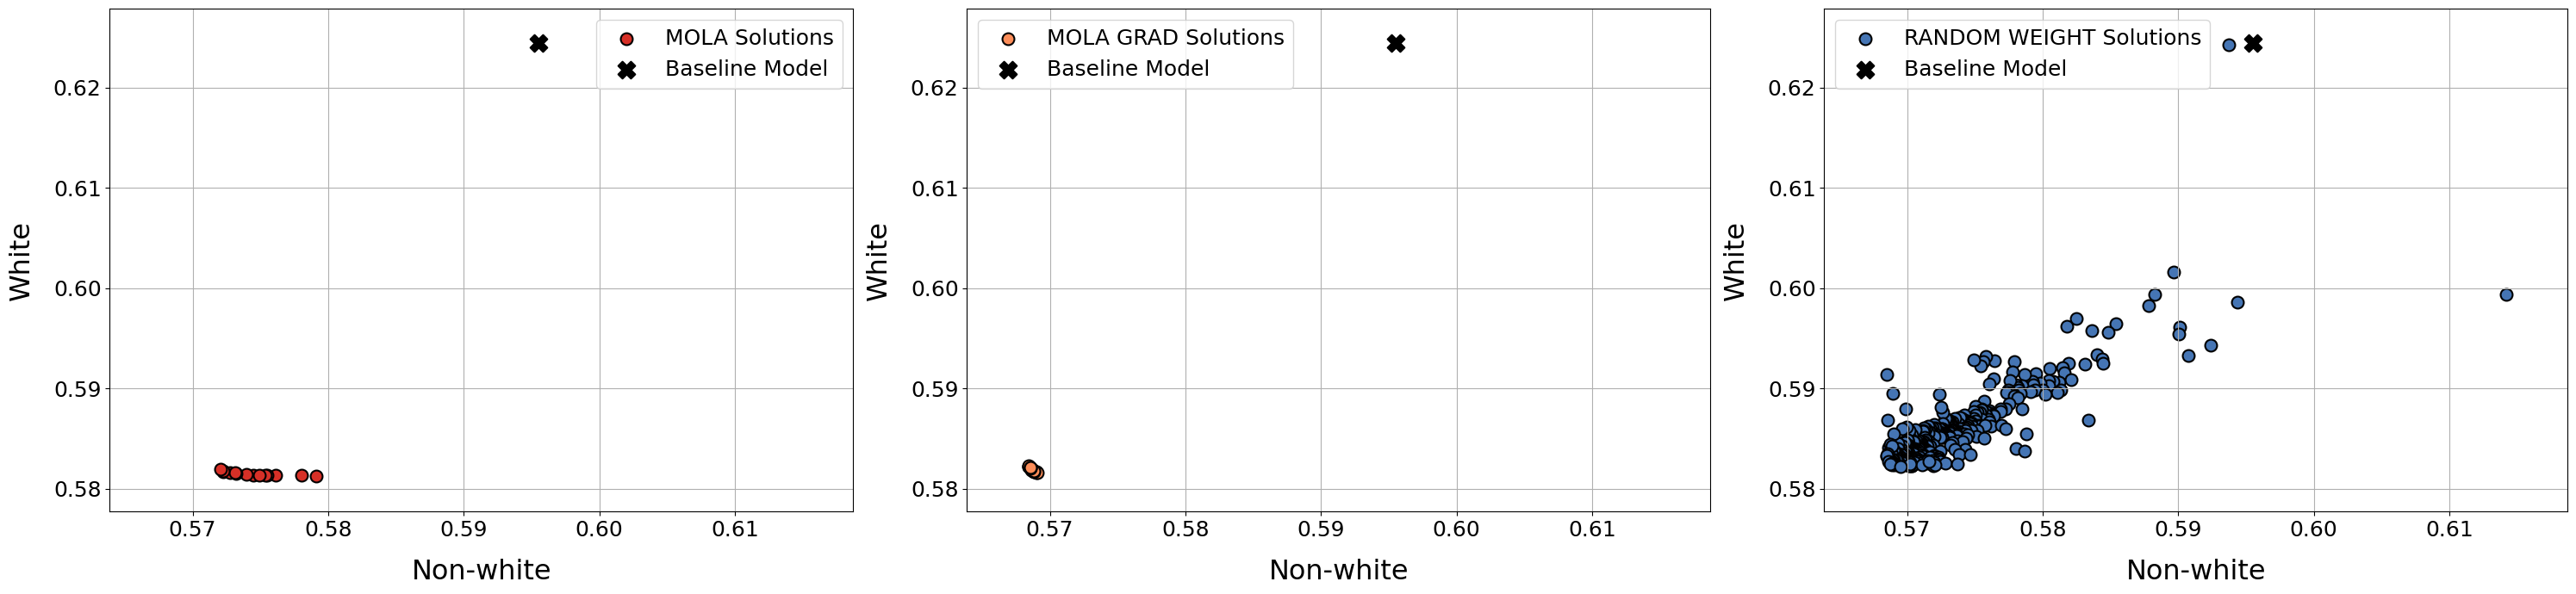

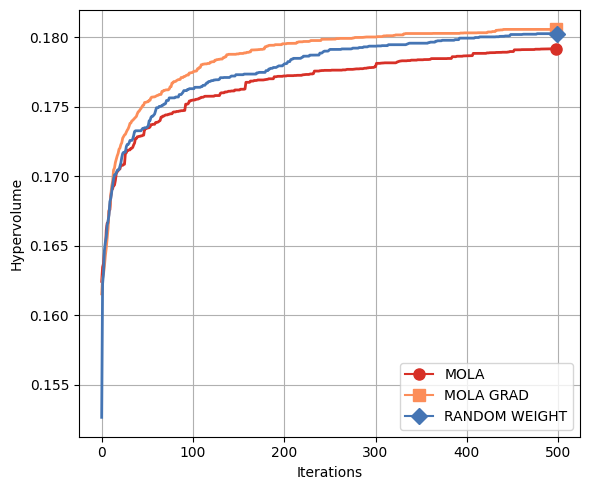

<Figure size 640x480 with 0 Axes>

In [44]:
pareto_dict = {
        method: res["objectives"]
        for method, res in results.items()
        if "objectives" in res
    }

hypervolumes_dict = {
        method: res["hypervolume"]
        for method, res in results.items()
        if "hypervolume" in res
    }

axes_label = ["Non-White", "White"]
plot_pareto(methods=pareto_dict,
            labels=axes_label, 
            title=title,
            point=equal.objs,
            fontsize=23,
            figsize=(10,7),
            save_path='images/2_objs_mlp_methods.pdf'
            )

plot_multiple_hypervolumes(methods_hv=hypervolumes_dict, save_path="images/2_objs_mlp_hypervolume.pdf")

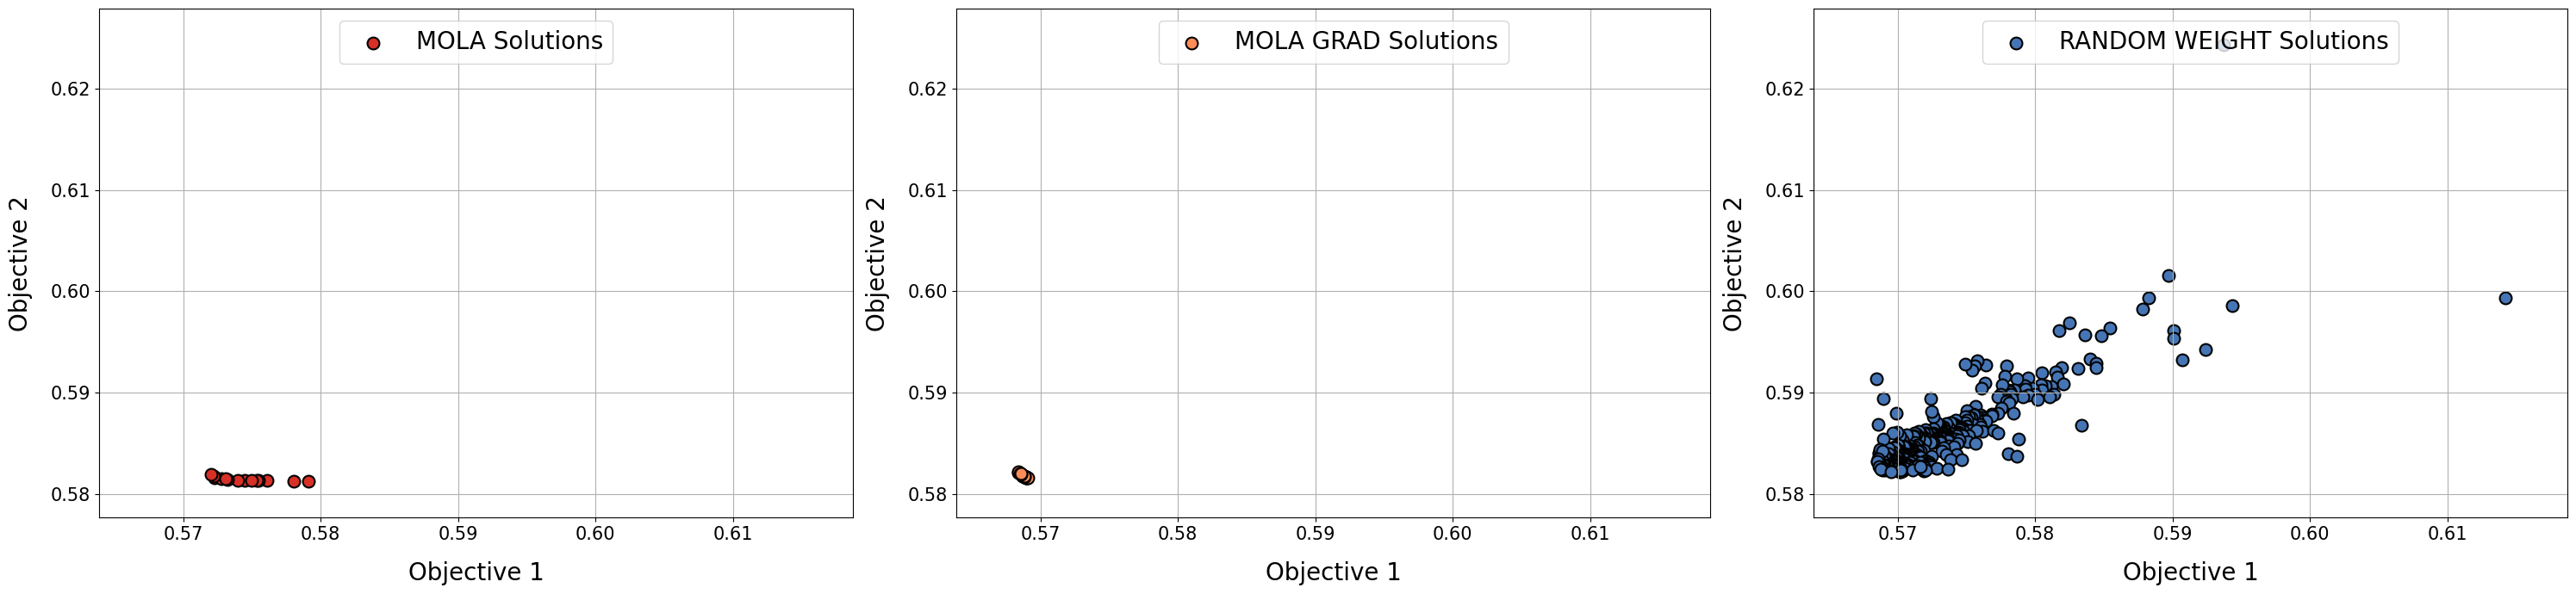

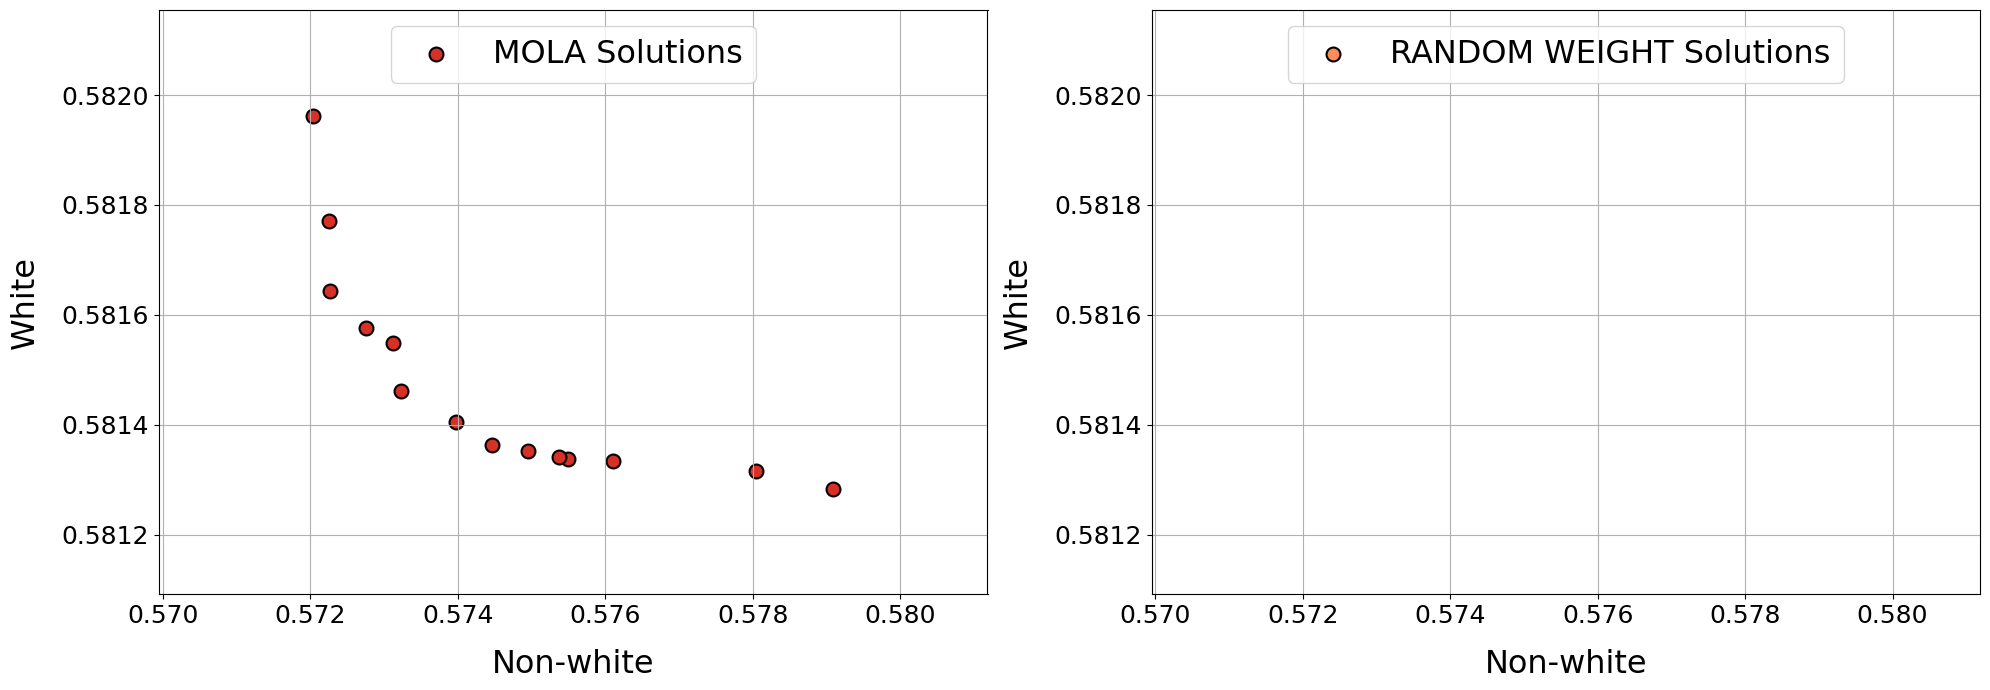

In [45]:
from machinemoo.analysis.visualization import plot_pareto_set_limit
plot_pareto_set_limit(methods=pareto_dict, axis_mode="global")
d = {
        method: res["objectives"]
        for method, res in results.items()
        if "objectives" in res and method != "mola_grad"
    }

plot_pareto_set_limit(methods=d, 
                      axis_mode="first", 
                      title="",
                      labels=axes_label, 
                      fontsize=23,
                      figsize=(10,7),
                      save_path="images/2_objs_mlp_limit.pdf")

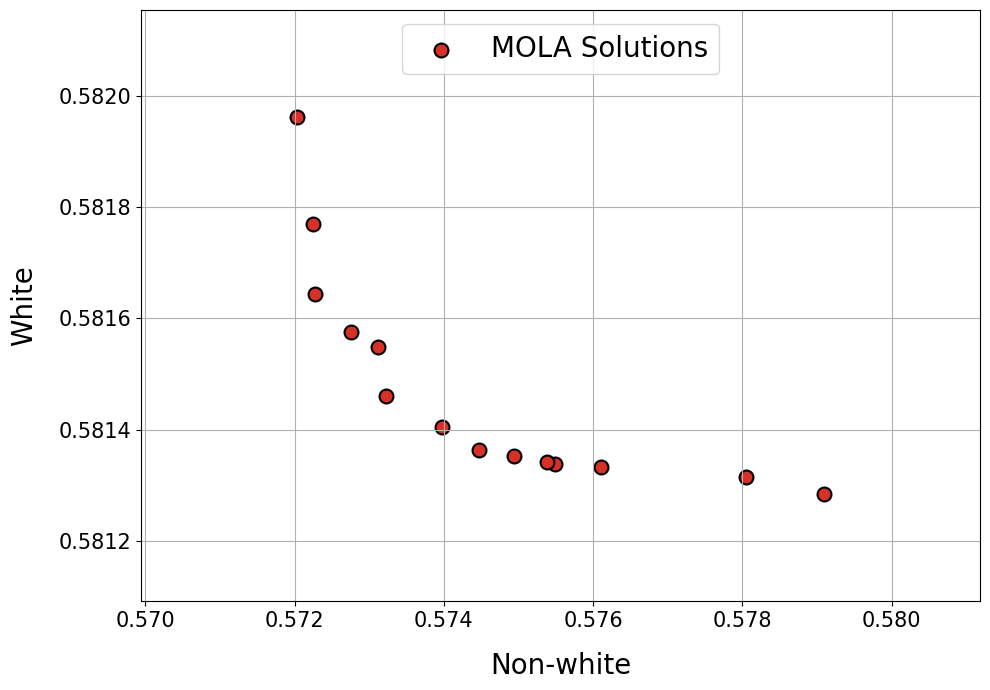

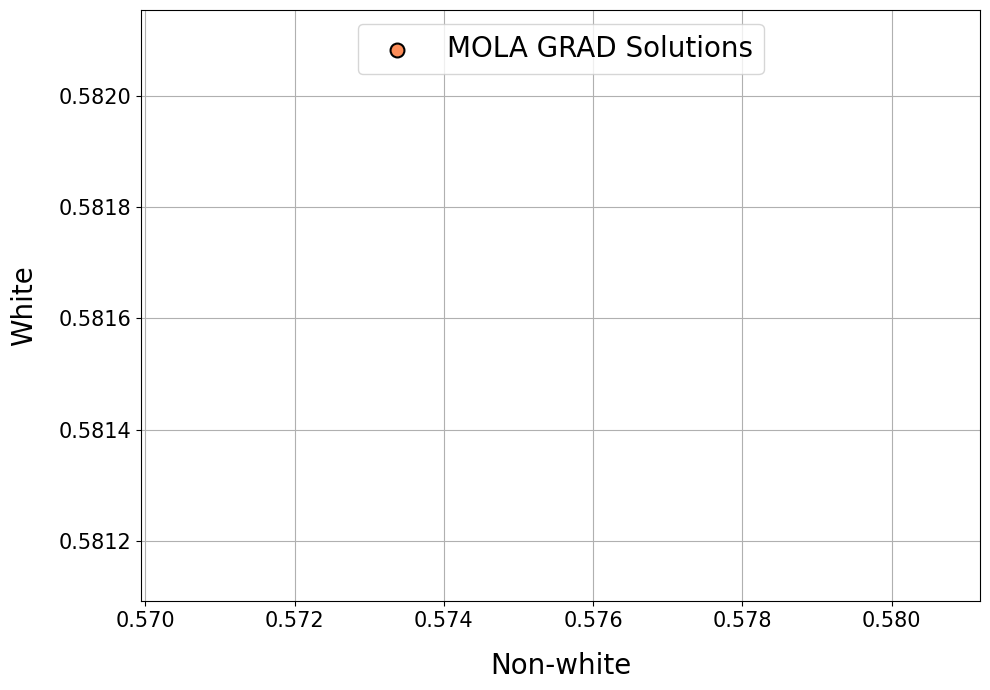

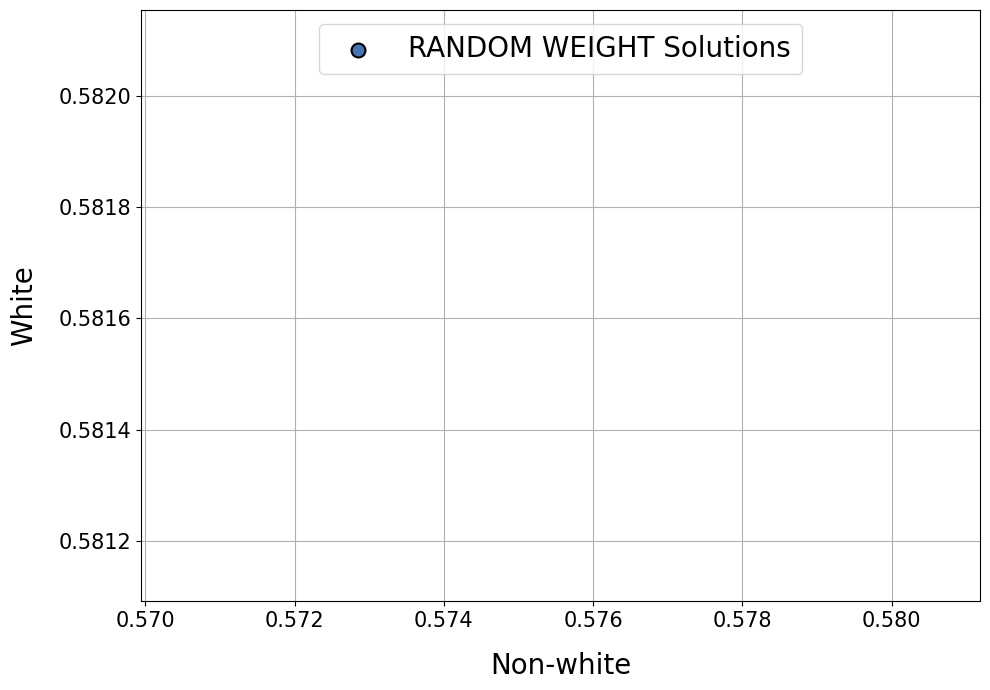

In [46]:
all_data = np.concatenate(list(pareto_dict.values()), axis=0)
limits = []
color: list[str] | str = ['#d73027', '#fc8d59', '#4575b4']

#for i in range(all_data.shape[1]):
#    limits.append(
#        (
#            all_data[:, i].min() - all_data[:, i].std(),
#            all_data[:, i].max() + all_data[:, i].std(),
#        )
#    )
first_objs = next(iter(pareto_dict.values()))
x_min, x_max = first_objs[:, 0].min() - first_objs[:, 0].std(), first_objs[:, 0].max() + first_objs[:, 0].std()
y_min, y_max = first_objs[:, 1].min() - first_objs[:, 1].std(), first_objs[:, 1].max() + first_objs[:, 1].std()

limits.append((x_min, x_max))
limits.append((y_min, y_max))

for i, (method, res) in enumerate(results.items()):
    plot_pareto(methods={method: res["objectives"]},
                color = color[i],
                labels=axes_label, 
                title=title,
                fontsize=20,
                figsize=(10,7),
                save_path=f'images/2_objs_mlp_{method}_limit.pdf',
                limits=limits
    )